# Mobile Accuracy Optimization: EfficientNet-B0 Quantization + YOLO26n 45-Epoch Training

This notebook is a focused deployment experiment based on:

- `training_and_log_v2.ipynb`
- `onnx_to_litert_conversion_ver2.ipynb`
- `tflite_inference_shrimp_disease_v2.ipynb`

Goals:

1. Keep the same processed-image loading, class order, and stratified 70/15/15 split used in the baseline notebook.
2. Train or reuse EfficientNet-B0, then export and compare multiple LiteRT/TFLite quantization levels.
3. Train `yolo26n-cls` for up to 45 epochs with early stopping, export to TFLite, and evaluate the exported model.
4. Compare all deployment artifacts on the same held-out test split only.

The final model-selection metric should be macro F1 first, then latency and size.

In [1]:
# Colab dependencies. Runtime restart may be needed if TensorFlow/onnx2tf packages are newly installed or changed.
%pip -q install ultralytics torchmetrics onnx onnxruntime onnxslim onnxscript tensorflow==2.19.1 tf-keras==2.19.0 ai-edge-litert onnx2tf==1.28.8 onnx-graphsurgeon sng4onnx pandas pillow matplotlib seaborn tqdm scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.9/152.9 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 469.2/469.2 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.4/238.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 50.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 85.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Configuration

The data loading and split mirror the baseline notebook. Outputs go to a new folder so this experiment does not overwrite the earlier baseline comparison.

In [3]:
import gc
import json
import os
import random
import shutil
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchmetrics
import torchvision.models as tv_models
from PIL import Image
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from ultralytics import YOLO

try:
    from ai_edge_litert.interpreter import Interpreter
    INTERPRETER_BACKEND = 'ai_edge_litert'
except Exception:
    import tensorflow as tf
    Interpreter = tf.lite.Interpreter
    INTERPRETER_BACKEND = 'tensorflow.lite'

import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Using TFLite interpreter backend: {INTERPRETER_BACKEND}')

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_REPRESENTATIVE_IMAGES = 256

# Keep the same source data folder used in training_and_log_v2.ipynb.
DATA_DIR = Path('/content/drive/MyDrive/shrimp_disease_images/Processed_Rembg_Images')

# Existing baseline location, used only for optional checkpoint reuse and for reference.
BASELINE_ROOT = Path('/content/drive/MyDrive/shrimp_disease_images/baseline_model_comparison')
BASELINE_EFFB0_CHECKPOINT = BASELINE_ROOT / 'checkpoints' / 'best_efficientnet_b0.pth'

# New output root for this experiment.
OUTPUT_DIR = Path('/content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
EXPORT_DIR = OUTPUT_DIR / 'exports'
TFLITE_DIR = OUTPUT_DIR / 'tflite'
SAVED_MODEL_DIR = OUTPUT_DIR / 'saved_models'
YOLO_DATA_DIR = OUTPUT_DIR / 'yolo_dataset'
YOLO_RUNS_DIR = OUTPUT_DIR / 'yolo_runs'
REPORT_DIR = OUTPUT_DIR / 'reports'
for d in [CHECKPOINT_DIR, EXPORT_DIR, TFLITE_DIR, SAVED_MODEL_DIR, YOLO_DATA_DIR, YOLO_RUNS_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CLASS_DIRS = ['1. Healthy', '2. BG', '3. WSSV', '4. WSSV_BG']
CLASS_NAMES = ['Healthy', 'BG', 'WSSV', 'WSSV_BG']
CLASS_TO_IDX = {folder: idx for idx, folder in enumerate(CLASS_DIRS)}
NUM_CLASSES = len(CLASS_NAMES)

# EfficientNet settings. If the baseline checkpoint exists, the notebook reuses it by default.
REUSE_BASELINE_EFFICIENTNET_CHECKPOINT = True
TRAIN_EFFICIENTNET_IF_NO_CHECKPOINT = True
EFFICIENTNET_EPOCHS = 15
EFFICIENTNET_PATIENCE = 3
EFFICIENTNET_LR = 1e-4

# YOLO26n extended training settings.
TRAIN_YOLO26N = True
YOLO_MODEL_NAME = 'yolo26n-cls'
YOLO_EPOCHS = 45
YOLO_PATIENCE = 10

print(f'Output root: {OUTPUT_DIR}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using device: cuda
Using TFLite interpreter backend: ai_edge_litert
Output root: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization


In [4]:
def discover_processed_images(data_dir: Path) -> pd.DataFrame:
    rows = []
    for class_dir in CLASS_DIRS:
        folder = data_dir / class_dir
        if not folder.exists():
            print(f'Warning: missing class folder: {folder}')
            continue
        for p in sorted(folder.iterdir()):
            if p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp'}:
                rows.append({'path': str(p), 'class_dir': class_dir, 'label': CLASS_TO_IDX[class_dir]})
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f'No images found under {data_dir}. Run the preprocessing cell first.')
    return df

df = discover_processed_images(DATA_DIR)
print(f'Loaded {len(df)} processed images from {DATA_DIR}')
print(df['class_dir'].value_counts().reindex(CLASS_DIRS))

train_df, tmp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['label'],
    random_state=SEED,
    shuffle=True,
)
val_df, test_df = train_test_split(
    tmp_df,
    test_size=0.50,
    stratify=tmp_df['label'],
    random_state=SEED,
    shuffle=True,
)

for name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    print(f'{name}: {len(split_df)} images')
    print(split_df['class_dir'].value_counts().reindex(CLASS_DIRS).to_dict())

train_paths = set(train_df['path'])
val_paths = set(val_df['path'])
test_paths = set(test_df['path'])
assert train_paths.isdisjoint(val_paths)
assert train_paths.isdisjoint(test_paths)
assert val_paths.isdisjoint(test_paths)
print('Image-level split overlap check passed.')

Loaded 1149 processed images from /content/drive/MyDrive/shrimp_disease_images/Processed_Rembg_Images
class_dir
1. Healthy    403
2. BG         198
3. WSSV       328
4. WSSV_BG    220
Name: count, dtype: int64
train: 804 images
{'1. Healthy': 282, '2. BG': 139, '3. WSSV': 229, '4. WSSV_BG': 154}
val: 172 images
{'1. Healthy': 60, '2. BG': 30, '3. WSSV': 49, '4. WSSV_BG': 33}
test: 173 images
{'1. Healthy': 61, '2. BG': 29, '3. WSSV': 50, '4. WSSV_BG': 33}
Image-level split overlap check passed.


In [5]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

torch_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN.tolist(), IMAGENET_STD.tolist()),
])

class ShrimpDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, int(row['label'])

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_generator = torch.Generator()
loader_generator.manual_seed(SEED)

train_loader = DataLoader(
    ShrimpDataset(train_df, torch_transform),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=loader_generator,
)
val_loader = DataLoader(ShrimpDataset(val_df, torch_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(ShrimpDataset(test_df, torch_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

## EfficientNet-B0: Train or Reuse, Export, Quantize

By default, this notebook reuses the previous EfficientNet-B0 checkpoint if it exists. If it is missing, it trains EfficientNet-B0 with the same architecture and optimizer settings from the baseline notebook.

Quantization levels produced:

- `float32`
- `dynamic_range`
- `float16`
- `full_int8`

The full-int8 converter uses representative images from the training split with the same ImageNet-normalized preprocessing used by EfficientNet-B0.

In [6]:
def macro_f1_metric():
    return torchmetrics.F1Score(task='multiclass', num_classes=NUM_CLASSES, average='macro').to(device)

def count_params(model) -> float:
    return sum(p.numel() for p in model.parameters()) / 1e6

def build_efficientnet_b0():
    weights = tv_models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model = tv_models.efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
    return model.to(device)

def evaluate_pytorch_model(model, loader, criterion=None, timed=False):
    model.eval()
    f1 = macro_f1_metric()
    correct = 0
    total = 0
    total_loss = 0.0

    if timed:
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
        with torch.no_grad():
            for _ in range(3):
                model(dummy)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
        start = time.time()
    else:
        start = None

    with torch.no_grad():
        for ims, gts in loader:
            ims = ims.to(device, non_blocking=True)
            gts = gts.to(device, non_blocking=True)
            logits = model(ims)
            if criterion is not None:
                total_loss += criterion(logits, gts).item() * ims.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == gts).sum().item()
            total += gts.size(0)
            f1.update(logits, gts)

    if timed and torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.time() - start if timed else None
    return {
        'loss': total_loss / max(1, total) if criterion is not None else None,
        'accuracy': correct / max(1, total),
        'macro_f1': f1.compute().item(),
        'elapsed': elapsed,
    }

def train_or_load_efficientnet_b0():
    best_path = CHECKPOINT_DIR / 'best_efficientnet_b0.pth'
    source_path = None
    if REUSE_BASELINE_EFFICIENTNET_CHECKPOINT and BASELINE_EFFB0_CHECKPOINT.exists():
        source_path = BASELINE_EFFB0_CHECKPOINT
    elif best_path.exists():
        source_path = best_path

    model = build_efficientnet_b0()

    if source_path is not None:
        model.load_state_dict(torch.load(source_path, map_location=device, weights_only=True))
        print(f'Loaded EfficientNet-B0 checkpoint: {source_path}')
        val_metrics = evaluate_pytorch_model(model, val_loader)
        test_metrics = evaluate_pytorch_model(model, test_loader, timed=True)
        return model, source_path, {
            'source': 'loaded_checkpoint',
            'checkpoint_path': str(source_path),
            'training_time_s': 0.0,
            'val_macro_f1': val_metrics['macro_f1'],
            'test_accuracy': test_metrics['accuracy'],
            'test_macro_f1': test_metrics['macro_f1'],
            'test_latency_ms': (test_metrics['elapsed'] / len(test_df)) * 1000,
        }

    if not TRAIN_EFFICIENTNET_IF_NO_CHECKPOINT:
        raise FileNotFoundError('No EfficientNet checkpoint found and TRAIN_EFFICIENTNET_IF_NO_CHECKPOINT=False.')

    optimizer = optim.AdamW(model.parameters(), lr=EFFICIENTNET_LR)
    criterion = nn.CrossEntropyLoss()
    best_f1 = -1.0
    epochs_no_improve = 0
    train_start = time.time()

    for epoch in range(EFFICIENTNET_EPOCHS):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        for ims, gts in tqdm(train_loader, desc=f'EfficientNet-B0 epoch {epoch + 1}/{EFFICIENTNET_EPOCHS}', leave=False):
            ims = ims.to(device, non_blocking=True)
            gts = gts.to(device, non_blocking=True)
            logits = model(ims)
            loss = criterion(logits, gts)

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * ims.size(0)
            train_correct += (torch.argmax(logits, dim=1) == gts).sum().item()
            train_total += gts.size(0)

        val_metrics = evaluate_pytorch_model(model, val_loader, criterion=criterion)
        train_acc = train_correct / max(1, train_total)
        print(
            f"Epoch {epoch + 1:02d}/{EFFICIENTNET_EPOCHS} | "
            f"Train Loss: {train_loss / max(1, train_total):.4f} - Acc: {train_acc:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} - Macro F1: {val_metrics['macro_f1']:.4f}"
        )

        if val_metrics['macro_f1'] > best_f1:
            best_f1 = val_metrics['macro_f1']
            epochs_no_improve = 0
            torch.save(model.state_dict(), best_path)
            print(f'  --> Saved best EfficientNet-B0 checkpoint: macro F1 {best_f1:.4f}')
        else:
            epochs_no_improve += 1
            print(f'  --> No improvement ({epochs_no_improve}/{EFFICIENTNET_PATIENCE})')

        if epochs_no_improve >= EFFICIENTNET_PATIENCE:
            print('  --> Early stopping triggered.')
            break

    training_time = time.time() - train_start
    model.load_state_dict(torch.load(best_path, map_location=device, weights_only=True))
    test_metrics = evaluate_pytorch_model(model, test_loader, timed=True)
    return model, best_path, {
        'source': 'trained',
        'checkpoint_path': str(best_path),
        'training_time_s': training_time,
        'val_macro_f1': best_f1,
        'test_accuracy': test_metrics['accuracy'],
        'test_macro_f1': test_metrics['macro_f1'],
        'test_latency_ms': (test_metrics['elapsed'] / len(test_df)) * 1000,
    }

efficientnet_model, efficientnet_checkpoint, efficientnet_train_record = train_or_load_efficientnet_b0()
print(json.dumps(efficientnet_train_record, indent=2))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 196MB/s]


Loaded EfficientNet-B0 checkpoint: /content/drive/MyDrive/shrimp_disease_images/baseline_model_comparison/checkpoints/best_efficientnet_b0.pth
{
  "source": "loaded_checkpoint",
  "checkpoint_path": "/content/drive/MyDrive/shrimp_disease_images/baseline_model_comparison/checkpoints/best_efficientnet_b0.pth",
  "training_time_s": 0.0,
  "val_macro_f1": 0.7781853675842285,
  "test_accuracy": 0.7398843930635838,
  "test_macro_f1": 0.7232232093811035,
  "test_latency_ms": 338.30007652326816
}


In [7]:
def run_command(cmd, cwd=None):
    print('Running:', ' '.join(map(str, cmd)))
    completed = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr)
    if completed.returncode != 0:
        raise RuntimeError(f'Command failed with exit code {completed.returncode}: {cmd}')
    return completed

def export_efficientnet_to_onnx(model):
    model_cpu = model.to('cpu').eval()
    sample = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
    onnx_path = EXPORT_DIR / 'efficientnet_b0_mobile_opt.onnx'
    torch.onnx.export(
        model_cpu,
        sample,
        str(onnx_path),
        input_names=['input'],
        output_names=['logits'],
        dynamic_axes={'input': {0: 'batch'}, 'logits': {0: 'batch'}},
        opset_version=17,
        dynamo=False,
    )
    model.to(device)
    print(f'Saved ONNX: {onnx_path}')
    return onnx_path

def convert_onnx_to_saved_model(onnx_path):
    out_dir = SAVED_MODEL_DIR / onnx_path.stem
    if out_dir.exists():
        shutil.rmtree(out_dir)
    run_command([
        sys.executable, '-m', 'onnx2tf',
        '-i', str(onnx_path),
        '-o', str(out_dir),
        '-osd',
    ])
    candidates = [p for p in out_dir.rglob('saved_model.pb')]
    if (out_dir / 'saved_model.pb').exists():
        saved_model_dir = out_dir
    elif candidates:
        saved_model_dir = candidates[0].parent
    else:
        raise FileNotFoundError(f'No saved_model.pb found under {out_dir}')
    print(f'Saved TensorFlow SavedModel: {saved_model_dir}')
    return saved_model_dir

onnx_path = export_efficientnet_to_onnx(efficientnet_model)
saved_model_path = convert_onnx_to_saved_model(onnx_path)

/tmp/ipykernel_592/109926305.py:16: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


Saved ONNX: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/exports/efficientnet_b0_mobile_opt.onnx
Running: /usr/bin/python3 -m onnx2tf -i /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/exports/efficientnet_b0_mobile_opt.onnx -o /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/saved_models/efficientnet_b0_mobile_opt -osd

Model optimizing started ============================================================
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnx2tf/onnx2tf.py", line 716, in convert
    result = subprocess.check_output(
             ^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/subprocess.py", line 466, in check_output
    return run(*popenargs, stdout=PIPE, timeout=timeout, check=True,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as p

In [8]:
def preprocess_pytorch_image_to_nhwc(image_path):
    image = Image.open(image_path).convert('RGB').resize((IMG_SIZE, IMG_SIZE))
    x = np.asarray(image, dtype=np.float32) / 255.0
    x = (x - IMAGENET_MEAN) / IMAGENET_STD
    return np.expand_dims(x, axis=0).astype(np.float32)

def representative_dataset():
    sample_df = train_df.groupby('class_dir', group_keys=False).apply(
        lambda group: group.sample(
            n=min(len(group), max(1, NUM_REPRESENTATIVE_IMAGES // NUM_CLASSES)),
            random_state=SEED,
        )
    ).reset_index(drop=True)
    if len(sample_df) < NUM_REPRESENTATIVE_IMAGES:
        remaining = train_df.drop(index=sample_df.index, errors='ignore')
        if not remaining.empty:
            extra = remaining.sample(n=min(len(remaining), NUM_REPRESENTATIVE_IMAGES - len(sample_df)), random_state=SEED)
            sample_df = pd.concat([sample_df, extra], ignore_index=True)

    for path in sample_df['path'].tolist():
        yield [preprocess_pytorch_image_to_nhwc(path)]

def convert_saved_model_to_tflite(saved_model_path, variant):
    converter = tf.lite.TFLiteConverter.from_saved_model(str(saved_model_path))

    if variant == 'float32':
        pass
    elif variant == 'dynamic_range':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
    elif variant == 'float16':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.target_spec.supported_types = [tf.float16]
    elif variant == 'full_int8':
        converter.optimizations = [tf.lite.Optimize.DEFAULT]
        converter.representative_dataset = representative_dataset
        converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
        converter.inference_input_type = tf.int8
        converter.inference_output_type = tf.int8
    else:
        raise ValueError(f'Unknown TFLite variant: {variant}')

    tflite_bytes = converter.convert()
    out_path = TFLITE_DIR / f'efficientnet_b0_{variant}.tflite'
    out_path.write_bytes(tflite_bytes)
    print(f'Saved {variant}: {out_path} ({out_path.stat().st_size / (1024 * 1024):.2f} MB)')
    return out_path

efficientnet_tflite_records = []
for variant in ['float32', 'dynamic_range', 'float16', 'full_int8']:
    try:
        t0 = time.time()
        path = convert_saved_model_to_tflite(saved_model_path, variant)
        efficientnet_tflite_records.append({
            'model_key': f'efficientnet_b0_{variant}',
            'model_family': 'pytorch_imagenet',
            'path': str(path),
            'status': 'converted',
            'size_mb': round(path.stat().st_size / (1024 * 1024), 2),
            'seconds': round(time.time() - t0, 1),
            'error': '',
        })
    except Exception as exc:
        efficientnet_tflite_records.append({
            'model_key': f'efficientnet_b0_{variant}',
            'model_family': 'pytorch_imagenet',
            'path': '',
            'status': 'failed',
            'size_mb': np.nan,
            'seconds': np.nan,
            'error': f'{type(exc).__name__}: {exc}',
        })

pd.DataFrame(efficientnet_tflite_records).to_csv(REPORT_DIR / 'efficientnet_quantization_report.csv', index=False)
display(pd.DataFrame(efficientnet_tflite_records))

Saved float32: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/tflite/efficientnet_b0_float32.tflite (15.29 MB)
Saved dynamic_range: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/tflite/efficientnet_b0_dynamic_range.tflite (4.32 MB)
Saved float16: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/tflite/efficientnet_b0_float16.tflite (7.69 MB)


/tmp/ipykernel_592/3592853764.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sample_df = train_df.groupby('class_dir', group_keys=False).apply(


Saved full_int8: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/tflite/efficientnet_b0_full_int8.tflite (4.66 MB)


,model_key,model_family,path,status,size_mb,seconds,error
0,efficientnet_b0_float32,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/m...,converted,15.29,3.1,
1,efficientnet_b0_dynamic_range,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/m...,converted,4.32,2.8,
2,efficientnet_b0_float16,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/m...,converted,7.69,1.9,
3,efficientnet_b0_full_int8,pytorch_imagenet,/content/drive/MyDrive/shrimp_disease_images/m...,converted,4.66,236.4,


## YOLO26n-cls: 45 Epochs with Early Stopping, Export to TFLite

This uses the same stratified split but writes a separate YOLO dataset under this experiment folder. Test images remain untouched until evaluation.

In [9]:
def prepare_yolo_dataset():
    if YOLO_DATA_DIR.exists():
        shutil.rmtree(YOLO_DATA_DIR)
    for split_name, split_df in [('train', train_df), ('val', val_df), ('test', test_df)]:
        for class_dir in CLASS_DIRS:
            (YOLO_DATA_DIR / split_name / class_dir).mkdir(parents=True, exist_ok=True)
        for _, row in split_df.iterrows():
            src = Path(row['path'])
            dst = YOLO_DATA_DIR / split_name / row['class_dir'] / src.name
            if dst.exists():
                stem = dst.stem
                suffix = dst.suffix
                dst = dst.with_name(f'{stem}_{abs(hash(str(src))) % 10_000_000}{suffix}')
            shutil.copy2(src, dst)
    print(f'Prepared YOLO classification dataset at {YOLO_DATA_DIR}')

prepare_yolo_dataset()

def yolo_device_arg():
    return 0 if torch.cuda.is_available() else 'cpu'

def train_yolo26n_extended():
    if not TRAIN_YOLO26N:
        existing = YOLO_RUNS_DIR / YOLO_MODEL_NAME / 'weights' / 'best.pt'
        if not existing.exists():
            raise FileNotFoundError(f'TRAIN_YOLO26N=False but no checkpoint found at {existing}')
        return existing, 0.0

    yolo = YOLO(f'{YOLO_MODEL_NAME}.pt')
    t0 = time.time()
    yolo.train(
        data=str(YOLO_DATA_DIR),
        task='classify',
        imgsz=IMG_SIZE,
        epochs=YOLO_EPOCHS,
        batch=BATCH_SIZE,
        patience=YOLO_PATIENCE,
        seed=SEED,
        project=str(YOLO_RUNS_DIR),
        name=YOLO_MODEL_NAME,
        exist_ok=True,
        device=yolo_device_arg(),
        verbose=True,
    )
    train_time = time.time() - t0
    best_path = YOLO_RUNS_DIR / YOLO_MODEL_NAME / 'weights' / 'best.pt'
    if not best_path.exists():
        candidates = sorted((YOLO_RUNS_DIR / YOLO_MODEL_NAME).glob('**/best.pt'))
        if not candidates:
            raise FileNotFoundError(f'Could not locate YOLO best checkpoint for {YOLO_MODEL_NAME}')
        best_path = candidates[-1]
    print(f'Best YOLO checkpoint: {best_path}')
    return best_path, train_time

yolo_best_pt, yolo_training_time = train_yolo26n_extended()

Prepared YOLO classification dataset at /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/yolo_dataset
Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/yolo_dataset, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=45, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mo

In [10]:
def export_yolo_tflite(best_pt):
    model = YOLO(str(best_pt))
    exported = model.export(format='tflite', imgsz=IMG_SIZE)
    exported_path = Path(exported)
    if not exported_path.exists():
        candidates = sorted(Path(best_pt).parent.glob('**/*.tflite')) + sorted(Path(best_pt).parents[0].glob('**/*.tflite'))
        if not candidates:
            raise FileNotFoundError('YOLO TFLite export reported success but no .tflite file was found.')
        exported_path = candidates[-1]
    print(f'Saved YOLO TFLite: {exported_path}')
    return exported_path

yolo_tflite_path = export_yolo_tflite(yolo_best_pt)
yolo_tflite_record = {
    'model_key': 'yolo26n-cls_45epoch_best',
    'model_family': 'yolo_ultralytics',
    'path': str(yolo_tflite_path),
    'status': 'converted',
    'size_mb': round(yolo_tflite_path.stat().st_size / (1024 * 1024), 2),
    'seconds': np.nan,
    'error': '',
    'training_time_s': round(yolo_training_time, 1),
}
print(json.dumps(yolo_tflite_record, indent=2))

Ultralytics 8.4.51 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO26n-cls summary (fused): 47 layers, 1,531,148 parameters, 0 gradients, 3.2 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/yolo_runs/yolo26n-cls/weights/best.pt' with input shape (1, 3, 224, 224) BCHW and output shape(s) (1, 4) (3.0 MB)
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 5 packages in 834ms
Prepared 1 package in 7.27s
Installed 1 package in 150ms
 + onnxruntime-gpu==1.26.0

requirements: AutoUpdate success ✅ 9.3s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.93...
ONNX: 

## TFLite-Only Held-Out Test Evaluation

Every artifact below is evaluated through a TFLite interpreter, not through PyTorch or Ultralytics prediction APIs. This makes the comparison closer to mobile deployment behavior.

In [11]:
def load_interpreter(model_path):
    interpreter = Interpreter(model_path=str(model_path))
    interpreter.allocate_tensors()
    return interpreter, interpreter.get_input_details()[0], interpreter.get_output_details()[0]

def infer_hw_from_input_shape(input_shape):
    shape = [int(x) for x in input_shape]
    if len(shape) != 4:
        return IMG_SIZE, IMG_SIZE, 'NHWC'
    if shape[1] == 3:
        return shape[2], shape[3], 'NCHW'
    return shape[1], shape[2], 'NHWC'

def preprocess_for_tflite(image_path, model_family, input_details):
    input_shape = input_details['shape']
    input_dtype = input_details['dtype']
    height, width, layout = infer_hw_from_input_shape(input_shape)

    image = Image.open(image_path).convert('RGB').resize((width, height))
    x = np.asarray(image, dtype=np.float32) / 255.0

    if model_family == 'pytorch_imagenet':
        x = (x - IMAGENET_MEAN) / IMAGENET_STD
    elif model_family == 'yolo_ultralytics':
        pass
    else:
        raise ValueError(f'Unknown model_family: {model_family}')

    if layout == 'NCHW':
        x = np.transpose(x, (2, 0, 1))
    x = np.expand_dims(x, axis=0)

    if np.issubdtype(input_dtype, np.integer):
        scale, zero_point = input_details.get('quantization', (0.0, 0))
        if scale and scale > 0:
            x = x / scale + zero_point
        info = np.iinfo(input_dtype)
        x = np.clip(np.rint(x), info.min, info.max).astype(input_dtype)
    else:
        x = x.astype(input_dtype)
    return x

def dequantize_output(y, output_details):
    y = np.asarray(y)
    if np.issubdtype(y.dtype, np.integer):
        scale, zero_point = output_details.get('quantization', (0.0, 0))
        if scale and scale > 0:
            y = (y.astype(np.float32) - zero_point) * scale
    return y

def as_probabilities(output):
    values = np.asarray(output).reshape(-1).astype(np.float64)
    if values.size == len(CLASS_NAMES) and np.all(values >= 0) and np.isclose(values.sum(), 1.0, atol=1e-3):
        return values.astype(np.float32)
    values = values - np.max(values)
    exp_values = np.exp(values)
    return (exp_values / exp_values.sum()).astype(np.float32)

def evaluate_tflite_model(model_key, model_family, model_path, eval_df):
    interpreter, input_details, output_details = load_interpreter(model_path)

    # Warmup outside timing.
    warmup_x = preprocess_for_tflite(eval_df.iloc[0]['path'], model_family, input_details)
    interpreter.set_tensor(input_details['index'], warmup_x)
    interpreter.invoke()

    rows = []
    start = time.perf_counter()
    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=model_key, leave=False):
        x = preprocess_for_tflite(row['path'], model_family, input_details)
        t0 = time.perf_counter()
        interpreter.set_tensor(input_details['index'], x)
        interpreter.invoke()
        latency_ms = (time.perf_counter() - t0) * 1000
        raw_output = interpreter.get_tensor(output_details['index'])
        raw_output = dequantize_output(raw_output, output_details)
        probs = as_probabilities(raw_output)
        pred_idx = int(np.argmax(probs))
        result = {
            'model_key': model_key,
            'model_family': model_family,
            'image_path': row['path'],
            'true_label': CLASS_NAMES[int(row['label'])],
            'predicted_label': CLASS_NAMES[pred_idx],
            'confidence': float(probs[pred_idx]),
            'latency_ms': latency_ms,
        }
        for class_name, prob in zip(CLASS_NAMES, probs):
            result[f'prob_{class_name}'] = float(prob)
        rows.append(result)
    elapsed = time.perf_counter() - start

    pred_df = pd.DataFrame(rows)
    summary = {
        'model_key': model_key,
        'model_family': model_family,
        'n_images': len(pred_df),
        'accuracy': accuracy_score(pred_df['true_label'], pred_df['predicted_label']),
        'macro_f1': f1_score(pred_df['true_label'], pred_df['predicted_label'], labels=CLASS_NAMES, average='macro', zero_division=0),
        'total_inference_time_s': elapsed,
        'mean_latency_ms': pred_df['latency_ms'].mean(),
        'fps': len(pred_df) / elapsed if elapsed > 0 else np.nan,
        'model_size_mb': round(Path(model_path).stat().st_size / (1024 * 1024), 2),
        'path': str(model_path),
    }
    return summary, pred_df

model_records = []
for record in efficientnet_tflite_records:
    if record['status'] == 'converted' and record['path']:
        model_records.append({
            'model_key': record['model_key'],
            'model_family': record['model_family'],
            'path': Path(record['path']),
        })
model_records.append({
    'model_key': yolo_tflite_record['model_key'],
    'model_family': yolo_tflite_record['model_family'],
    'path': Path(yolo_tflite_record['path']),
})

eval_summaries = []
prediction_frames = []
for record in model_records:
    try:
        summary, pred_df = evaluate_tflite_model(record['model_key'], record['model_family'], record['path'], test_df)
        eval_summaries.append(summary)
        prediction_frames.append(pred_df)
    except Exception as exc:
        eval_summaries.append({
            'model_key': record['model_key'],
            'model_family': record['model_family'],
            'n_images': len(test_df),
            'accuracy': np.nan,
            'macro_f1': np.nan,
            'total_inference_time_s': np.nan,
            'mean_latency_ms': np.nan,
            'fps': np.nan,
            'model_size_mb': round(Path(record['path']).stat().st_size / (1024 * 1024), 2) if Path(record['path']).exists() else np.nan,
            'path': str(record['path']),
            'error': f'{type(exc).__name__}: {exc}',
        })

eval_summary_df = pd.DataFrame(eval_summaries).sort_values('macro_f1', ascending=False, na_position='last').reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True) if prediction_frames else pd.DataFrame()

summary_csv = REPORT_DIR / 'mobile_optimization_tflite_test_summary.csv'
pred_csv = REPORT_DIR / 'mobile_optimization_tflite_test_predictions.csv'
summary_json = REPORT_DIR / 'mobile_optimization_tflite_test_summary.json'
eval_summary_df.to_csv(summary_csv, index=False)
eval_summary_df.to_json(summary_json, orient='records', indent=2)
if not predictions_df.empty:
    predictions_df.to_csv(pred_csv, index=False)

print(f'Saved summary: {summary_csv}')
print(f'Saved predictions: {pred_csv}')
display(eval_summary_df)

efficientnet_b0_float32:   0%|          | 0/173 [00:00<?, ?it/s]

efficientnet_b0_dynamic_range:   0%|          | 0/173 [00:00<?, ?it/s]

efficientnet_b0_float16:   0%|          | 0/173 [00:00<?, ?it/s]

efficientnet_b0_full_int8:   0%|          | 0/173 [00:00<?, ?it/s]

yolo26n-cls_45epoch_best:   0%|          | 0/173 [00:00<?, ?it/s]

Saved summary: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/reports/mobile_optimization_tflite_test_summary.csv
Saved predictions: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/reports/mobile_optimization_tflite_test_predictions.csv


,model_key,model_family,n_images,accuracy,macro_f1,total_inference_time_s,mean_latency_ms,fps,model_size_mb,path
0,yolo26n-cls_45epoch_best,yolo_ultralytics,173,0.820809,0.809483,11.989000,7.196524,14.429895,5.88,/content/drive/MyDrive/shrimp_disease_images/m...
1,efficientnet_b0_float16,pytorch_imagenet,173,0.751445,0.736497,14.558838,20.719974,11.882816,7.69,/content/drive/MyDrive/shrimp_disease_images/m...
2,efficientnet_b0_float32,pytorch_imagenet,173,0.745665,0.730999,14.488173,20.743457,11.940774,15.29,/content/drive/MyDrive/shrimp_disease_images/m...
3,efficientnet_b0_dynamic_range,pytorch_imagenet,173,0.641618,0.640004,16.663179,34.912883,10.382173,4.32,/content/drive/MyDrive/shrimp_disease_images/m...
4,efficientnet_b0_full_int8,pytorch_imagenet,173,0.271676,0.239519,13.806284,17.853354,12.530526,4.66,/content/drive/MyDrive/shrimp_disease_images/m...


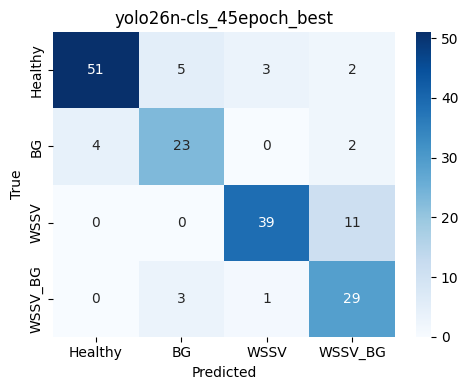

Saved: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/reports/confusion_matrix_yolo26n-cls_45epoch_best.png


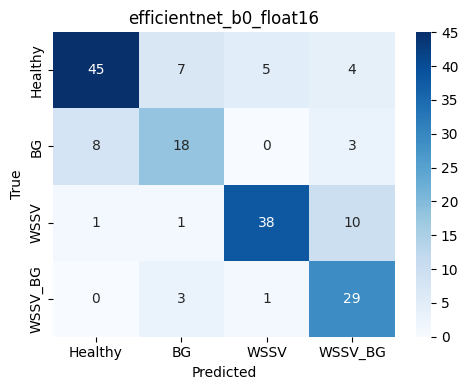

Saved: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/reports/confusion_matrix_efficientnet_b0_float16.png


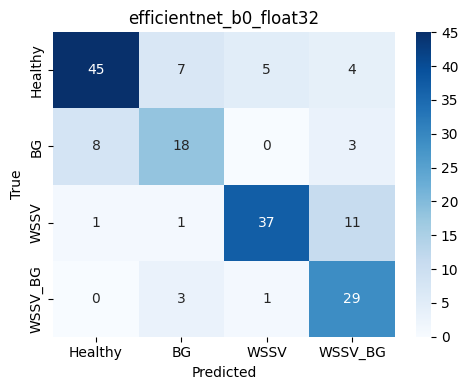

Saved: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/reports/confusion_matrix_efficientnet_b0_float32.png


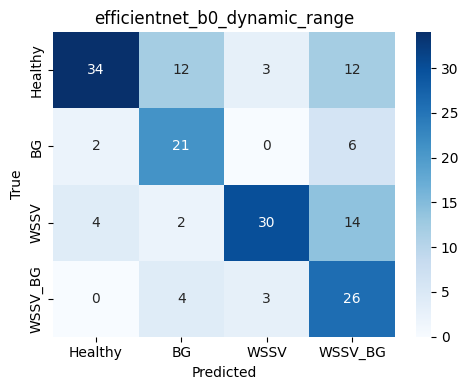

Saved: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/reports/confusion_matrix_efficientnet_b0_dynamic_range.png


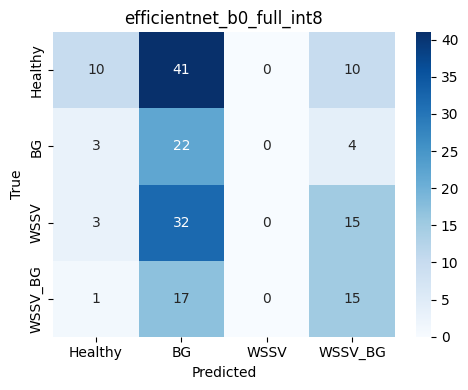

Saved: /content/drive/MyDrive/shrimp_disease_images/mobile_accuracy_optimization/reports/confusion_matrix_efficientnet_b0_full_int8.png


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

if not predictions_df.empty:
    for model_key in eval_summary_df['model_key'].dropna().tolist():
        model_preds = predictions_df[predictions_df['model_key'] == model_key]
        if model_preds.empty:
            continue
        cm = confusion_matrix(model_preds['true_label'], model_preds['predicted_label'], labels=CLASS_NAMES)
        plt.figure(figsize=(5, 4))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap='Blues')
        plt.title(model_key)
        plt.xlabel('Predicted')
        plt.ylabel('True')
        plt.tight_layout()
        fig_path = REPORT_DIR / f'confusion_matrix_{model_key}.png'
        plt.savefig(fig_path, dpi=160)
        plt.show()
        print(f'Saved: {fig_path}')

## How to Read the Result

Prefer the model with the best held-out test macro F1 if accuracy retention is the priority.

For mobile deployment, also compare:

- `model_size_mb`
- `mean_latency_ms`
- per-class confusion matrices

If `efficientnet_b0_full_int8` drops more than a few macro-F1 points from `efficientnet_b0_float32`, keep float32 or use YOLO26n. If `yolo26n-cls_45epoch_best` improves over the previous 15-epoch export without class-specific collapse, it is likely the best mobile candidate because it was already faster and stronger on the held-out test set.